
# Neural Network Architectures for Audio (EdgeAI Friendly)

This notebook is both:
- 📘 Teaching slides
- 🧪 Hands-on lab

We explore:
- single_fc
- conv
- low_latency_conv
- low_latency_svdf
- RNN (LSTM)

Goal:
Understand **how models capture time in audio** and why some work better on embedded systems.



## Step 0 — Audio as Data (MFCC / Spectrogram)

Audio is converted into a 2D representation:

- X-axis → time
- Y-axis → frequency
- Values → energy

Shape example:
```
time_steps × frequency_bins (e.g., 49 × 10)
```

This is why we can use CNNs (like images).
![audio](https://drive.google.com/uc?export=view&id=1wzohg_ynLA4zSupX_qlIwVlqvyUI_7-D)

In [1]:

import numpy as np
import matplotlib.pyplot as plt


In [2]:

# Simulated MFCC-like data
def generate_fake_mfcc(samples=1000, time_steps=20, freq_bins=10, classes=3):
    X = np.random.randn(samples, time_steps, freq_bins)
    y = np.random.randint(0, classes, samples)
    return X, y

X, y = generate_fake_mfcc()
X.shape, y.shape


((1000, 20, 10), (1000,))

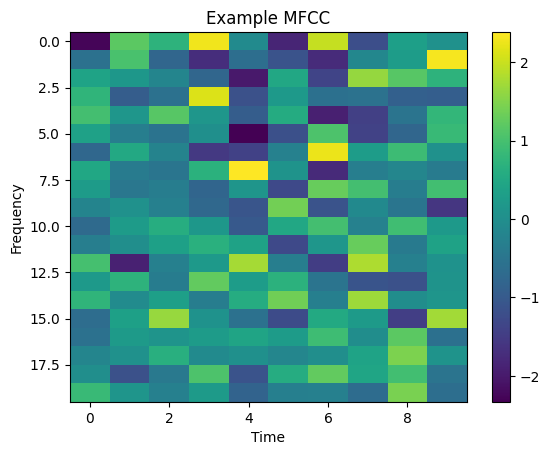

In [3]:

plt.imshow(X[0], aspect='auto')
plt.title("Example MFCC")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.show()



## Step 1 — single_fc (No Time Awareness)

Flatten everything → Dense layer

**Key idea:** Model does NOT understand time.


In [4]:

from sklearn.neural_network import MLPClassifier

X_flat = X.reshape(X.shape[0], -1)

model_fc = MLPClassifier(hidden_layer_sizes=(32,), max_iter=5)
model_fc.fit(X_flat, y)

print("FC training accuracy:", model_fc.score(X_flat, y))


FC training accuracy: 0.441


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(



## Step 2 — CNN (Local Pattern Recognition)
Concept

- Apply 2D convolutions over time-frequency
- Learns local patterns in time-frequency space.

![cnn](https://drive.google.com/uc?export=view&id=1wcw9C85tAhKL18RG41n6SCeajL_47kto)

In [5]:

# Simple CNN using tensorflow (if available)
try:
    import tensorflow as tf

    model_cnn = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(20,10,1)),
        tf.keras.layers.Conv2D(8, (3,3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    X_cnn = X[..., np.newaxis]

    model_cnn.fit(X_cnn, y, epochs=2, verbose=0)

    print("CNN training complete")
except Exception as e:
    print("TensorFlow not available:", e)


CNN training complete



## Step 3 — SVDF (single value decomposition filter)
Approximate a fully-connected layer with a low rank approximation.

`option = low_latency_svdf`

### Efficient temporal modeling.

Think of it as:
- A compressed RNN
- Keeps memory over time
- Optimized for microcontrollers

👉 This is usually the BEST choice for EdgeAI keyword spotting example.




In [ ]:
# ASSIGNMENT NOTEBOOK "Wake Word"


## Step 4 — RNN (LSTM)

True sequence modeling.

Pros:
- Captures long-term dependencies

Cons (critical for OpenMV):
- High RAM usage
- Slow inference
- Poor TFLite Micro support

![cnn](https://drive.google.com/uc?export=view&id=1iSQAxHfh6YPDfNFLS0LrF5w6BKq9hQUx)


In [6]:

# Optional LSTM demo
try:
    import tensorflow as tf

    model_lstm = tf.keras.Sequential([
        tf.keras.layers.LSTM(16, input_shape=(20,10)),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

    model_lstm.fit(X, y, epochs=2, verbose=0)

    print("LSTM training complete")
except Exception as e:
    print("TensorFlow not available:", e)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM training complete



## Final Comparison

| Model | Time Awareness | Embedded Suitability |
|------|---------------|---------------------|
| single_fc | ❌ | ⭐⭐⭐⭐⭐ |
| CNN | ⚠️ | ⭐⭐⭐ |
| low_latency_conv | ⚠️ | ⭐⭐⭐⭐ |
| SVDF | ✅ | ⭐⭐⭐⭐⭐ |
| LSTM | ✅ | ⭐ |

---

## Key Takeaway

We don't avoid RNNs because they are bad.

We avoid them because:
👉 **Hardware constraints force better approximations (SVDF).**

![compare](https://drive.google.com/uc?export=view&id=1GC-LsinSDTaVq01qvPMZoqsTbyj9475S)

## Interpretation

### CNN
- Learns local time-frequency patterns
- Good accuracy
- Limited temporal memory

### SVDF
- Efficient temporal memory
- Excellent for streaming inference
- Very MCU-friendly

### RNN / LSTM
- True sequence model
- Best temporal modeling
- Computationally expensive

## Key Insight

SVDF is essentially:
> "An embedded-friendly approximation of temporal sequence modeling."

# RNN vs. SVDF
![RNN](https://drive.google.com/uc?export=view&id=1iSQAxHfh6YPDfNFLS0LrF5w6BKq9hQUx)

Left side: inputs from multiple time steps
```
x(t−T), ..., x(t), ..., x(t+T)
```
Each block = feature vector at a time slice
All arrows go into a single summation node

###The key idea (this is the “aha” moment)

**SVDF = “look at multiple time steps, but compress the computation”**

Instead of doing a full dense layer over all time:
It splits weights into two parts:
- feature weights (frequency)
- time weights (temporal memory)

###Mathematically:

W ≈ α × β   (low-rank factorization)

*Which reduces compute dramatically*

### The intuitive explanation

*This is basically a sliding time window where each past frame contributes—with learned importance—to the current decision.*

### Or even simpler:

“SVDF remembers the past, but cheaply.”

### Connect it to something they already understand

Compare to:

- CNN:
→ looks at local patches

- RNN:
→ keeps hidden state

- SVDF:
→ keeps a fixed-size memory buffer + weighted sum

### A really good analogy:

`SVDF = FIFO buffer + learned filter over time`

# 🔷 Summary
```
Time steps →   t-3   t-2   t-1    t
                ↓     ↓     ↓     ↓
               [x]   [x]   [x]   [x]
                \     |     |     /
                 \    |     |    /
                  ---- weighted sum ----
                          ↓
                       output
```

- “weights over time” = temporal filter
- “weights over features” = projection